# Appendix 5. The 3D and 4D embeddings

Draw the higher dimensional embeddings of appendix 4, coloured by the same
`DB_label`.  A supernova above `RATIO_THRESHOLD` is a small circle, one below it
a larger star or diamond; a table with no `ratio` column draws every point as a
circle.

| input | what it provides |
| --- | --- |
| `results/umap_5100_6450_dim3_nei12_eps0475_lab2d.csv` | the 3D embedding of appendix 4 |
| `results/umap_5100_6450_dim4_nei12_eps0475_lab2d.csv` | the 4D embedding of appendix 4 |

| output | what it shows |
| --- | --- |
| `figure/umap_3d.pdf` | the static 3D scatter plot, for the paper |
| `html/umap_3d_interactive.html` | the same, rotatable and hoverable (Plotly) |
| `html/umap_4d_interactive.html` | the 4D embedding in four 3D projections, with a dropdown |


## 1. Setup


In [1]:
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

### 1.1 Plot style


In [2]:
plt.rcParams.update({
    'figure.figsize': (7.0, 7.0),
    'figure.dpi': 300,
    'font.family': 'Arial',

    # ticks inward, on all four sides
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.bottom': True,
    'xtick.top': True,
    'ytick.left': True,
    'ytick.right': True,

    # minor ticks
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,

    # tick widths and lengths
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
})

### 1.2 Paths and common settings


In [ ]:
RESULTS_DIR = Path('./results')

FIGURE_DIR = Path('./figure')
HTML_DIR = Path('./html')

# Coordinate columns of the 3D / 4D tables
COORDS_3D = ('umap_x', 'umap_y', 'umap_z')
COORDS_4D = ('umap_x', 'umap_y', 'umap_z', 'umap_w')

LABEL_COL = 'DB_label'

# A supernova above this ratio gets the plain marker, one below it the emphasized one
RATIO_THRESHOLD = 0.7

# Hover columns; only those present in the table are used.
# The supernova name is deliberately left out so that it is not shown.
OPTIONAL_HOVER_COLS = ('SN_type', 'ratio')

### 1.3 Cluster colours and labels

`DB_label` mapped to a colour and a legend name.  The order of this dictionary is
the order of the legend.


In [4]:
db12_settings = {
     3: {'color': 'tab:blue',   'label': 'cluster 0 (NV1+91T)'},
     5: {'color': 'tab:orange', 'label': 'cluster 1 (NV2)'},
     1: {'color': 'tab:green',  'label': 'cluster 2 (HV)'},
     4: {'color': 'tab:red',    'label': 'cluster 3 (91bg)'},
     0: {'color': 'tab:purple', 'label': 'cluster 4 (Iax)'},
     2: {'color': 'tab:brown',  'label': 'cluster 5 (others 1)'},
    -1: {'color': 'tab:grey',   'label': 'cluster 6 (others 2)'},
}

### 1.4 Helpers


In [5]:
def prepare(data, coords):
    """Check the required columns, then drop rows with no `DB_label` and cast it to int."""
    required = list(coords) + [LABEL_COL]
    missing = [col for col in required if col not in data.columns]
    if missing:
        raise ValueError(
            f'missing columns: {missing}\n'
            f'columns present: {list(data.columns)}'
        )

    data = data.dropna(subset=[LABEL_COL]).copy()
    data[LABEL_COL] = data[LABEL_COL].astype(int)
    return data


def split_by_ratio(cluster, threshold=RATIO_THRESHOLD):
    """Split the rows of one cluster into (ratio above threshold, below).

    A table with no `ratio` column puts every row in the first half and returns
    an empty DataFrame as the second.
    """
    if 'ratio' not in cluster.columns:
        return cluster, cluster.iloc[:0]

    return (
        cluster[cluster['ratio'] > threshold],
        cluster[cluster['ratio'] <= threshold],
    )


def iter_clusters(data, settings):
    """Yield (label, setting, rows of that cluster) in the order of `settings`.

    A cluster with no rows is skipped, so the legend follows the order in which
    `settings` is written.
    """
    for label, setting in settings.items():
        cluster = data[data[LABEL_COL] == label]
        if not cluster.empty:
            yield label, setting, cluster

In [6]:
def hover_columns(data, coords):
    """The hover columns: those present in the table, without duplicates."""
    columns = [col for col in OPTIONAL_HOVER_COLS if col in data.columns]
    columns += list(coords) + [LABEL_COL]
    return list(dict.fromkeys(columns))


def hovertemplate(columns, cluster_name):
    """The Plotly hovertemplate matching the order of `customdata`."""
    numeric = set(COORDS_4D) | {'ratio'}

    lines = [
        f'{col}=%{{customdata[{i}]:.3f}}' if col in numeric
        else f'{col}=%{{customdata[{i}]}}'
        for i, col in enumerate(columns)
    ]
    return '<br>'.join(lines) + f'<extra>{cluster_name}</extra>'

## 2. Static 3D plot (matplotlib)


In [7]:
# Data for the static plot: the 3D coordinates carrying the 2D cluster labels
data_3d_lab2d = pd.read_csv(
    RESULTS_DIR / 'umap_5100_6450_dim3_nei12_eps0475_lab2d.csv'
)

In [8]:
# (marker, size) for the rows above / below RATIO_THRESHOLD
MPL_MARKERS = (('o', 24), ('*', 70))

def plot_umap_3d(
    data,
    output,
    settings=db12_settings,
    elev=25,
    azim=45,
    legend_loc='upper left',
):
    """Scatter plot of the 3D UMAP space, saved to `figure/<output>`.

    Parameters
    ----------
    data : DataFrame
        Table holding `umap_x`, `umap_y`, `umap_z` and `DB_label`.
    output : str
        File name to save under (e.g. ``'umap_3d.pdf'``).
    settings : dict
        {label: {'color', 'label'}}, in the form of `db12_settings`.
    elev, azim : float
        Elevation and azimuth of the view.
    """
    data = prepare(data, COORDS_3D)
    xcol, ycol, zcol = COORDS_3D

    fig = plt.figure(figsize=(6.5, 6.0))
    ax = fig.add_subplot(111, projection='3d')

    for _, setting, cluster in iter_clusters(data, settings):
        # one legend entry per cluster
        legend_label = setting['label']

        for subset, (marker, size) in zip(split_by_ratio(cluster), MPL_MARKERS):
            if subset.empty:
                continue

            ax.scatter(
                subset[xcol], subset[ycol], subset[zcol],
                marker=marker,
                c=setting['color'],
                s=size,
                linewidths=0.3,
                alpha=0.7,
                label=legend_label,
            )
            legend_label = None

    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_zlabel('Dimension 3', labelpad=2)
    ax.view_init(elev=elev, azim=azim)

    # if ax.get_legend_handles_labels()[0]:
    #     ax.legend(loc=legend_loc, fontsize=8)

    fig.subplots_adjust(
        left=0.02,
        right=0.6,
        bottom=0.02,
        top=0.98,
    )

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        FIGURE_DIR / output,
        bbox_inches='tight',
        pad_inches=0.2,
    )

    plt.show()
    return fig

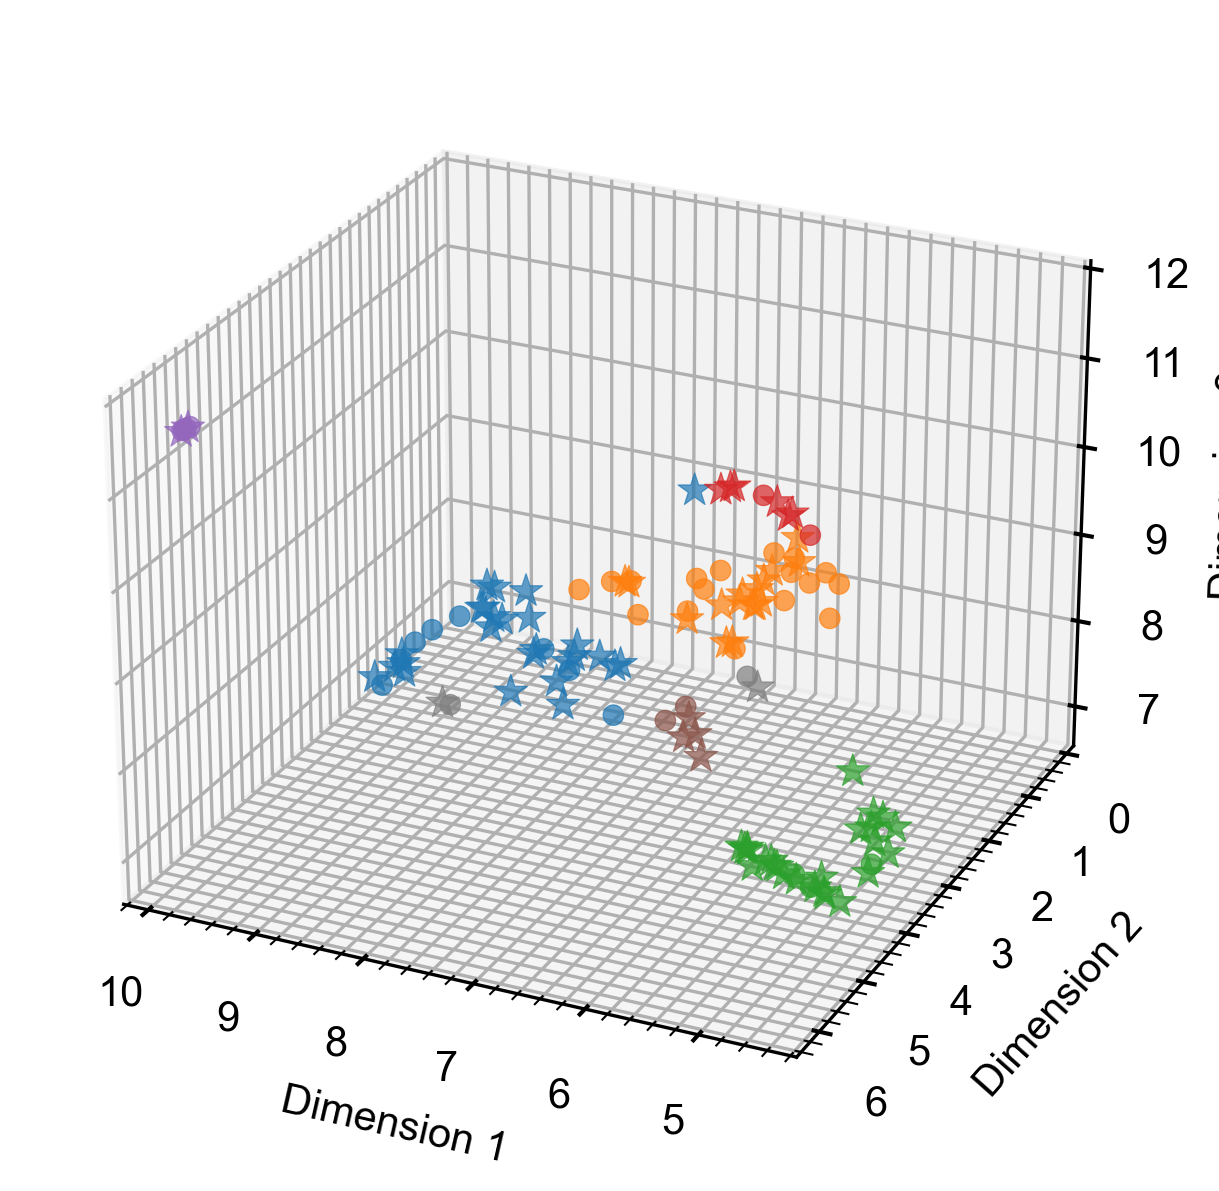

In [9]:
plot_umap_3d(data_3d_lab2d, 'umap_3d.pdf', elev=25, azim=115);

## 3. Interactive plots (Plotly)

The 3D and 4D figures build their traces the same way, so both call
`add_cluster_traces()`.


In [10]:
# Markers for the points above / below RATIO_THRESHOLD
PLOTLY_MARKERS = (
    dict(size=4, symbol='circle'),
    dict(size=7, symbol='diamond'),
)


def add_cluster_traces(
    fig,
    data,
    dims,
    settings,
    hover_cols,
    visible=True,
    show_legend=True,
):
    """Add one Scatter3d per cluster to `fig`, on the three columns of `dims`.

    The ratio split makes two traces per cluster; `legendgroup` ties them
    together so that the legend shows one entry per cluster.

    Returns
    -------
    list[int]
        Indices of the added traces in `fig.data`.
    """
    xcol, ycol, zcol = dims
    added = []

    for label, setting, cluster in iter_clusters(data, settings):
        # Plotly cannot read matplotlib names such as 'tab:blue'
        color = to_hex(setting['color'])
        cluster_name = setting['label']

        # only the first trace of a cluster carries the legend
        needs_legend = show_legend

        for subset, marker in zip(split_by_ratio(cluster), PLOTLY_MARKERS):
            if subset.empty:
                continue

            fig.add_trace(
                go.Scatter3d(
                    x=subset[xcol],
                    y=subset[ycol],
                    z=subset[zcol],
                    mode='markers',
                    name=cluster_name,
                    legendgroup=str(label),
                    showlegend=needs_legend,
                    visible=visible,
                    marker=dict(color=color, opacity=0.75, **marker),
                    customdata=subset[hover_cols].values,
                    hovertemplate=hovertemplate(hover_cols, cluster_name),
                )
            )

            added.append(len(fig.data) - 1)
            needs_legend = False

    return added


def save_html(fig, output_html, open_browser=True):
    """Write the figure out as HTML, optionally opening it in a browser."""
    output_html = Path(output_html)
    output_html.parent.mkdir(parents=True, exist_ok=True)
    fig.write_html(output_html, auto_open=open_browser)
    return output_html

### 3.1 3D UMAP


In [11]:
def plot_umap_3d_interactive(
    data,
    output_html=HTML_DIR / 'umap_3d_interactive.html',
    settings=db12_settings,
    title='3D UMAP',
    open_browser=True,
):
    """A rotatable, hoverable 3D scatter plot, saved as HTML."""
    data = prepare(data, COORDS_3D)

    fig = go.Figure()
    add_cluster_traces(
        fig,
        data,
        COORDS_3D,
        settings,
        hover_cols=hover_columns(data, COORDS_3D),
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='Dimension 1',
            yaxis_title='Dimension 2',
            zaxis_title='Dimension 3',
        ),
        legend=dict(x=0.01, y=0.99),
        margin=dict(l=0, r=0, b=0, t=40),
    )

    save_html(fig, output_html, open_browser)
    return fig

In [12]:
fig_3d = plot_umap_3d_interactive(
    data_3d_lab2d,
    output_html=HTML_DIR / 'umap_3d_interactive.html',
    title='3D UMAP with DBSCAN labels',
)

### 3.2 4D UMAP

Four dimensions cannot be drawn at once, so all four 3-of-4 projections
(XYZ / XYW / XZW / YZW) are drawn and a dropdown switches between them.


In [13]:
data_4d_lab2d = pd.read_csv(
    RESULTS_DIR / 'umap_5100_6450_dim4_nei12_eps0475_lab2d.csv'
)

# The 3-of-4 axis combinations; the first one is shown on load.
PROJECTIONS_4D = {
    'XYZ': ('umap_x', 'umap_y', 'umap_z'),
    'XYW': ('umap_x', 'umap_y', 'umap_w'),
    'XZW': ('umap_x', 'umap_z', 'umap_w'),
    'YZW': ('umap_y', 'umap_z', 'umap_w'),
}

DEFAULT_PROJECTION = 'XYZ'


def plot_umap_4d_interactive(
    data,
    output_html=HTML_DIR / 'umap_4d_interactive.html',
    settings=db12_settings,
    title='4D UMAP',
    open_browser=True,
):
    """The 4D UMAP drawn in four 3D projections, saved as HTML with a selector."""
    data = prepare(data, COORDS_4D)
    hover_cols = hover_columns(data, COORDS_4D)

    fig = go.Figure()

    # Add the traces of each projection, remembering which belong to which
    trace_groups = {
        name: add_cluster_traces(
            fig,
            data,
            dims,
            settings,
            hover_cols=hover_cols,
            visible=(name == DEFAULT_PROJECTION),
            show_legend=(name == DEFAULT_PROJECTION),
        )
        for name, dims in PROJECTIONS_4D.items()
    }

    fig.update_layout(
        title=f'{title}: {DEFAULT_PROJECTION}',
        scene=dict(
            xaxis_title=PROJECTIONS_4D[DEFAULT_PROJECTION][0],
            yaxis_title=PROJECTIONS_4D[DEFAULT_PROJECTION][1],
            zaxis_title=PROJECTIONS_4D[DEFAULT_PROJECTION][2],
            aspectmode='data',
        ),
        updatemenus=[
            dict(
                buttons=_projection_buttons(fig, trace_groups, title),
                direction='down',
                x=0.02,
                y=1.08,
                xanchor='left',
                yanchor='top',
            )
        ],
        legend=dict(x=0.01, y=0.98, font=dict(size=10)),
        margin=dict(l=0, r=0, b=0, t=70),
    )

    save_html(fig, output_html, open_browser)
    return fig


def _projection_buttons(fig, trace_groups, title):
    """The dropdown buttons that switch between the projections."""
    buttons = []

    for name, (xcol, ycol, zcol) in PROJECTIONS_4D.items():
        # show only the traces of that projection
        visible = [False] * len(fig.data)
        for index in trace_groups[name]:
            visible[index] = True

        buttons.append(
            dict(
                label=name,
                method='update',
                args=[
                    {'visible': visible},
                    {
                        'title': f'{title}: {name}',
                        'scene.xaxis.title.text': xcol,
                        'scene.yaxis.title.text': ycol,
                        'scene.zaxis.title.text': zcol,
                    },
                ],
            )
        )

    return buttons

In [14]:
fig_4d = plot_umap_4d_interactive(
    data_4d_lab2d,
    output_html=HTML_DIR / 'umap_4d_interactive.html',
    title='4D UMAP with HDBSCAN labels',
)